# Coulomb dam break on a sloping bed — AVAC

This Chapter 8 benchmark combines a 5° incline with Coulomb basal resistance and compares AVAC's quasi-one-dimensional centerline with the analytical boundaries and profiles.


## Reproducible environment

The first code cell installs the repository's validation package and Python dependencies into the active kernel. A clean checkout also needs GNU Make and gfortran to compile the selected solver on first use.


In [1]:
from pathlib import Path
SEARCH_ROOT = Path.cwd().resolve()
REPOSITORY = next(candidate for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents) if (candidate / 'validation' / 'pyproject.toml').is_file())
%pip install -q -e {REPOSITORY / 'validation'}


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from avac4qgis_validation import validation_case
case = validation_case('AVAC', 'Coulomb_sloping_bed')
CORES = max(1, os.cpu_count() or 1)
case.path


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/AVAC/Coulomb_sloping_bed')

## Physical and numerical definition

The released depth is $H_0=1$ m, the Coulomb coefficient is $\mu=0.2$, and the bed angle is 5°. A five-cell transverse strip preserves the intended one-dimensional state. Three AMR levels refine narrow corridors around the independently known boundary paths from a 30 mm base mesh to a 1.875 mm finest mesh; this is finer at the fronts than the preceding 2.5 mm result.


In [3]:
BASE_DX_M = 0.03
AMR_LEVELS = 3
AMR_RATIO = 4
SPEED_TOLERANCE_M_S = 0.02
T_FINAL_S = 6.0
OUTPUT_FRAMES = 30
RUN_NAME = os.environ.get('AVAC_VALIDATION_RUN_NAME', 'publication_amr')
case.run('run_avac_validation.py', '--dx', BASE_DX_M, '--ny', 5, '--t-final', T_FINAL_S, '--nout', OUTPUT_FRAMES, '--case-name', RUN_NAME, '--cores', CORES, '--amr-levels', AMR_LEVELS, '--amr-ratio', AMR_RATIO, '--speed-tolerance', SPEED_TOLERANCE_M_S, '--max1d', 1000, '--replace')


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/AVAC/Coulomb_sloping_bed/run_avac_validation.py --dx 0.03 --ny 5 --t-final 6.0 --nout 30 --case-name publication_amr --cores 8 --amr-levels 3 --amr-ratio 4 --speed-tolerance 0.02 --max1d 1000 --replace
* computational domain x = [-10.00, 20.00] m, nx = 1000
* computational domain y = [0.00, 0.15] m, ny = 5
*** WARNING: Selective output_aux_components not implemented
***          Will output all components of aux
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/python/geoclaw/data.py:199: UserWarning: 
  *** WARNING: topofile specs changed in v5.8.0 -- Flag level info now ignored
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/python/geoclaw/data.py:142: UserWarning: 
  *** WARNING: deep_depth parameter ignored as of v5.8.0
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14

In [4]:
summary = case.json(f'{RUN_NAME}/results/summary.json')
summary


{'amr_levels': 3,
 'refinement_ratios': [4, 4],
 'transverse_refinement_ratios': [1, 1],
 'base_dx_m': 0.03,
 'finest_dx_m': 0.001875,
 'speed_tolerance_m_s': 0.02,
 'amr_flagging': 'prescribed moving front corridors',
 'forced_region_count': 240,
 'fgout_nx': 16000,
 'fgout_ny': 1,
 'fgmax_enabled': False,
 'max1d': 1000,
 'solver': '/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/src/AVAC/xgeoclaw',
 'solver_sha256': '6e85bee646c3d4730693b70323c7195ca84dc1b6a075d9ea1b803624838310f9',
 'source_setrun': '/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/src/AVAC/setrun.py',
 'clawpack_source': '/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0',
 'dx_m': 0.03,
 'dy_m': 0.03,
 'ny': 5,
 'xlower_m': -10.0,
 'xupper_m': 20.0,
 'slope_degrees': -5.0,
 'mu': 0.2,
 'gravity_m_s2': 9.81,
 'initial_depth_m': 1.0,
 't_final_s': 6.0,
 'outputs': 30,
 'cfl_desired': 0.25,
 'cfl_max': 0.5,
 'dry_tolerance_m': 1e-12,
 'limiter': 'Superbee',
 'corridor_interval_s': 0.05,
 'corridor_margin_m': 0.

## Analytical comparison


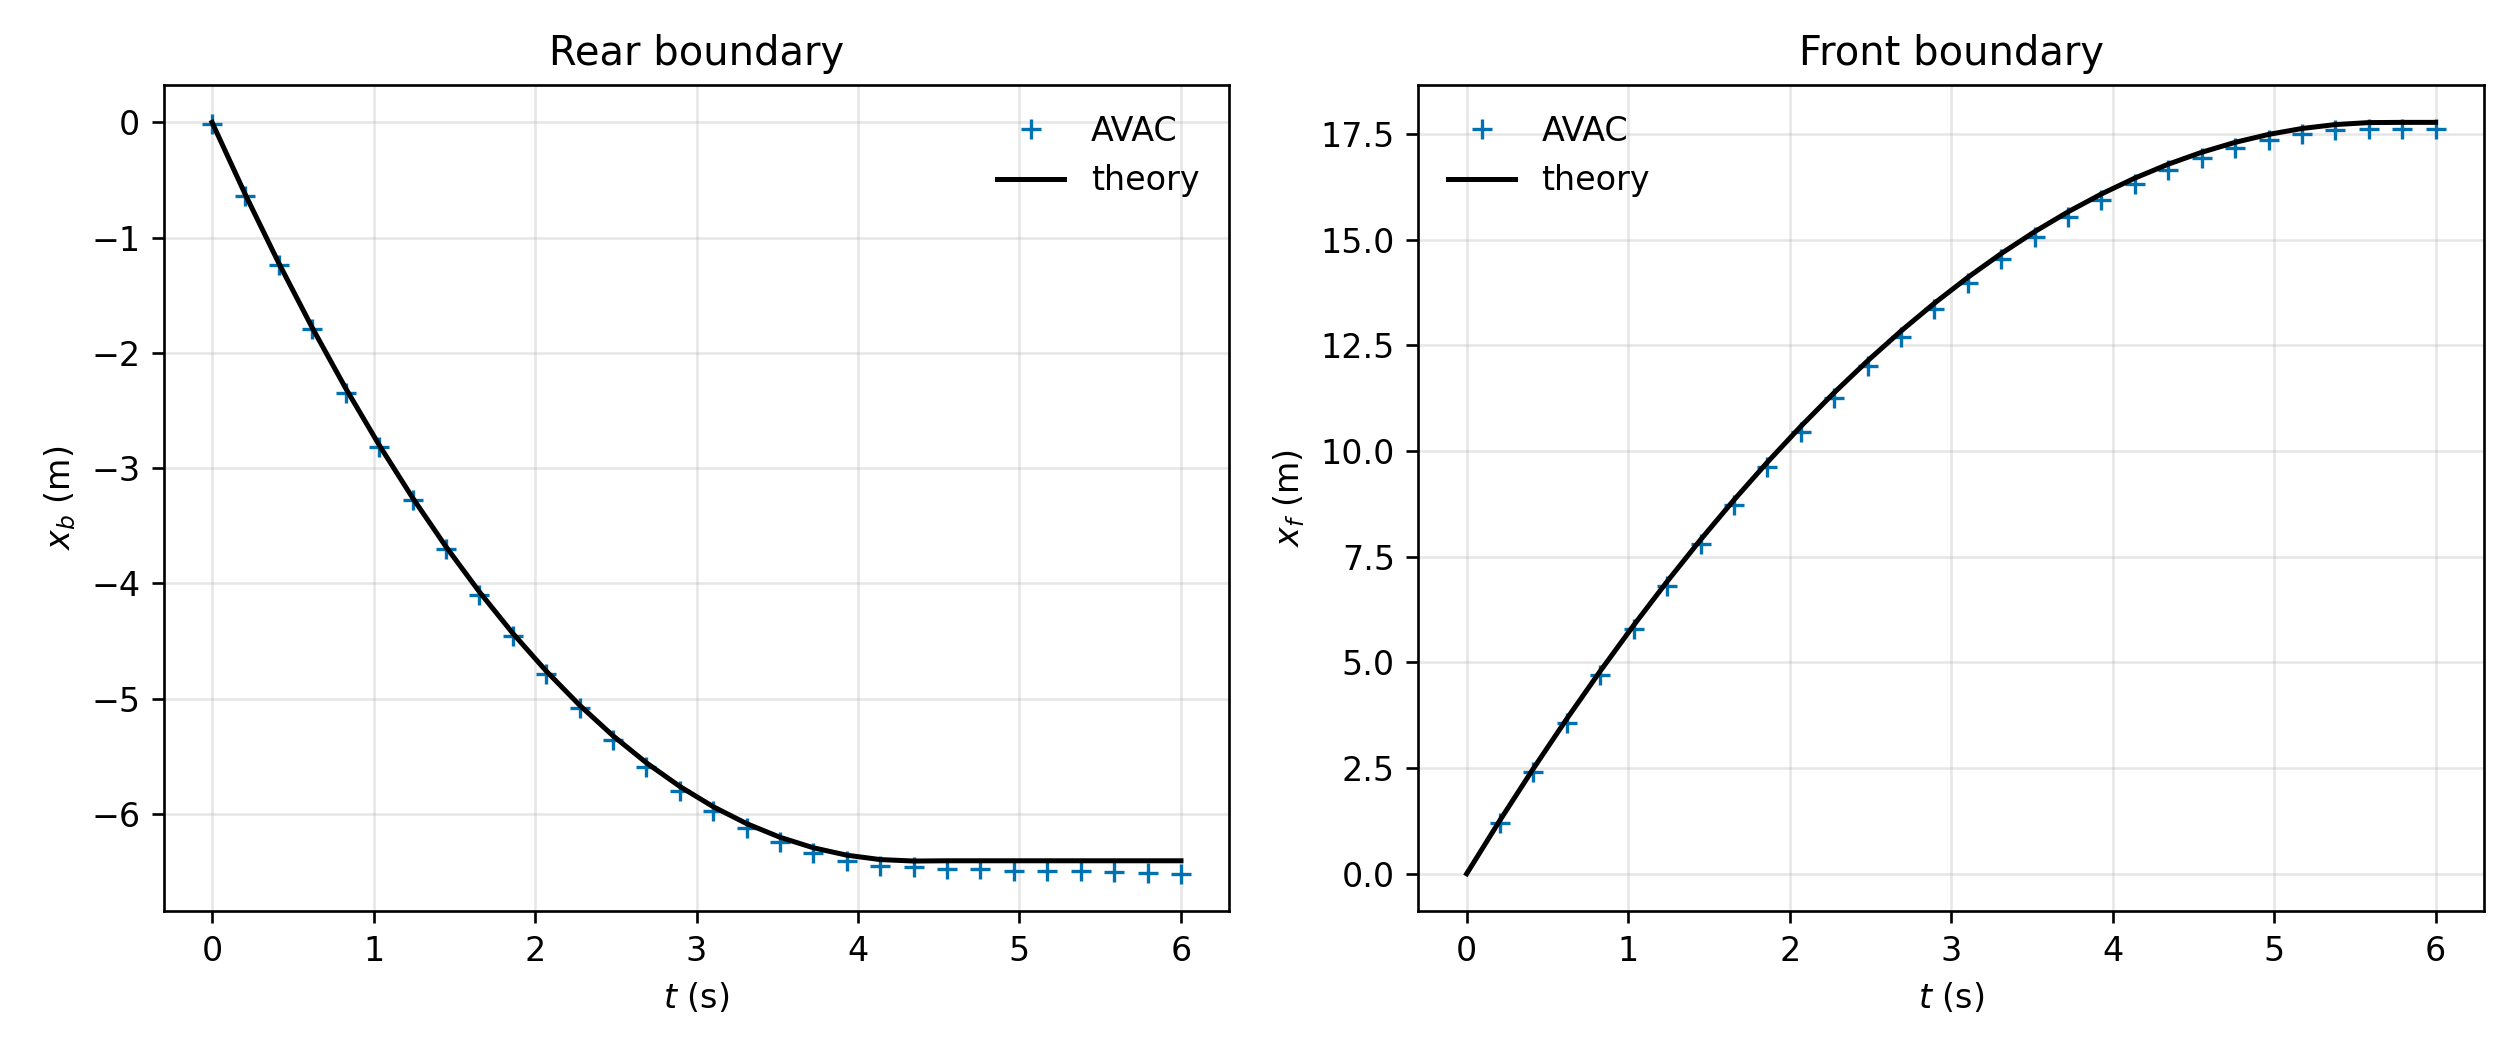

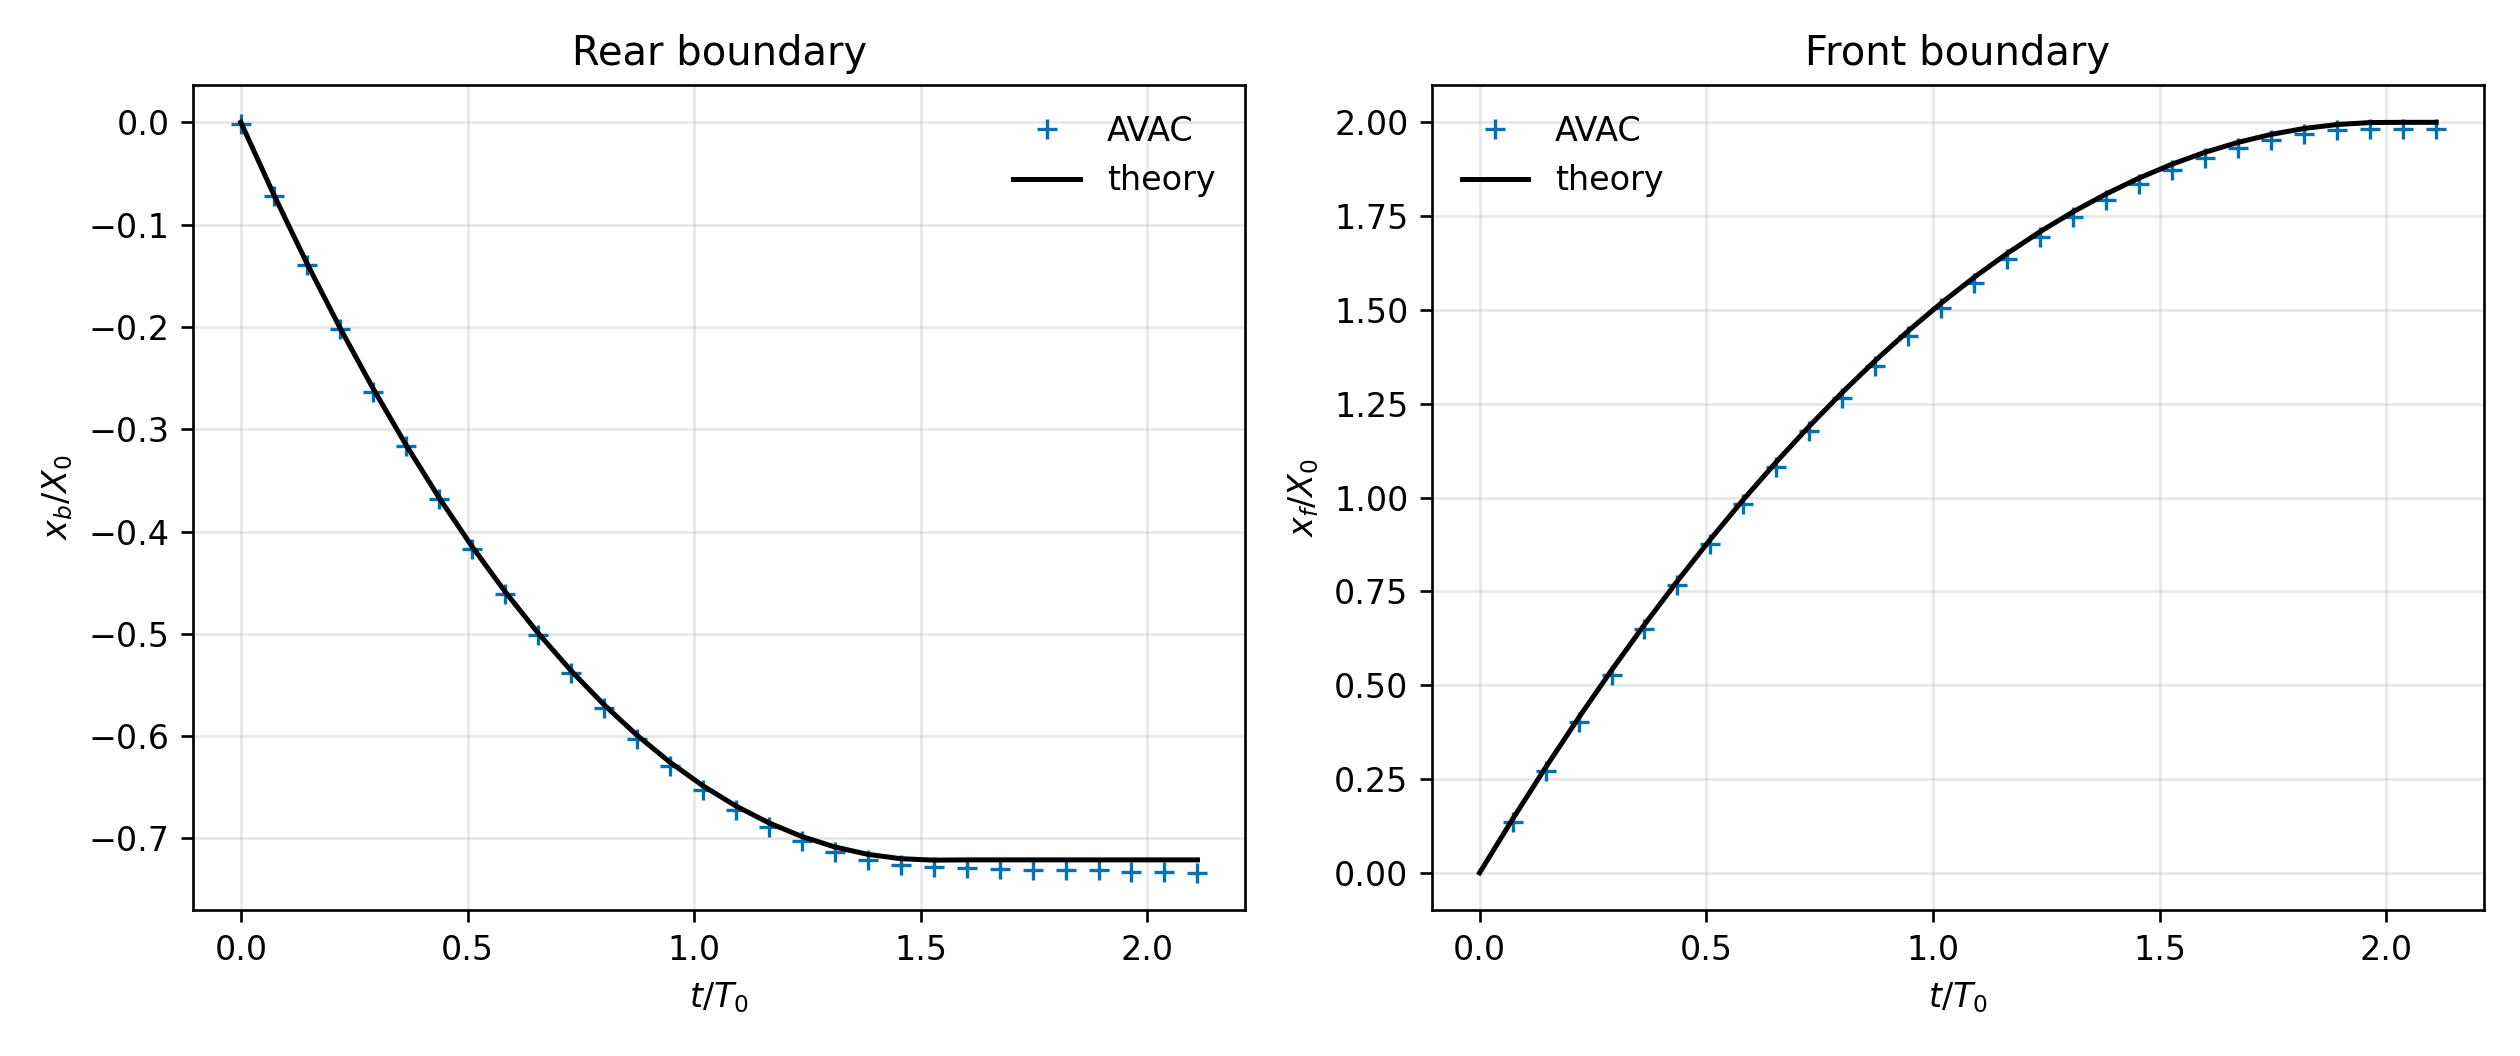

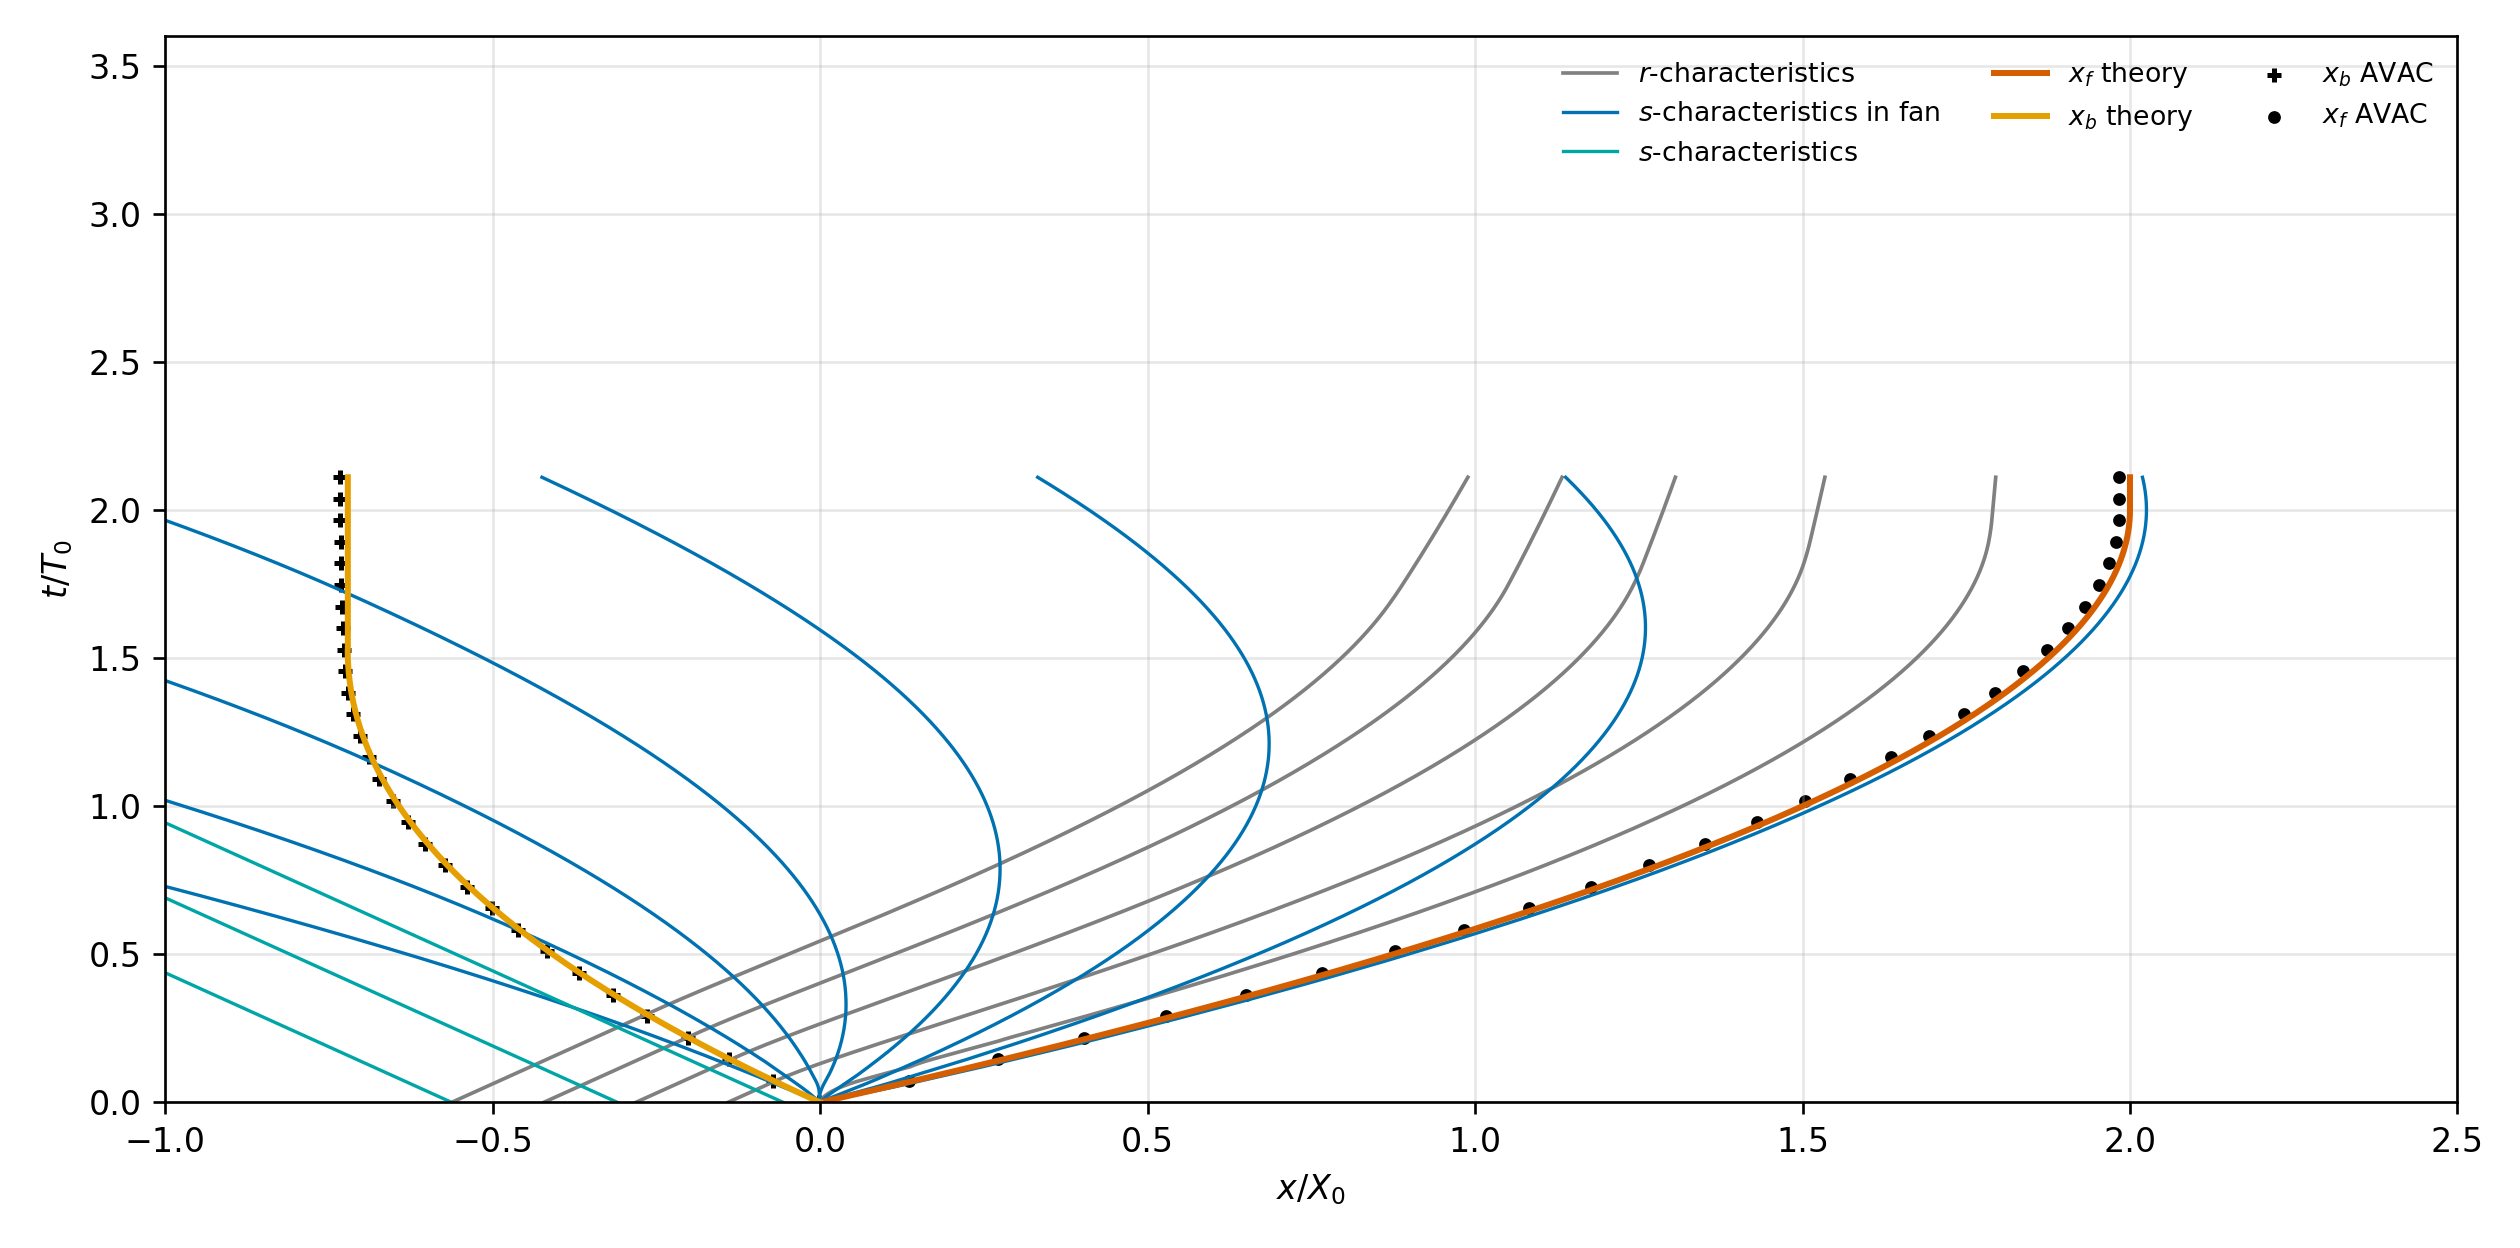

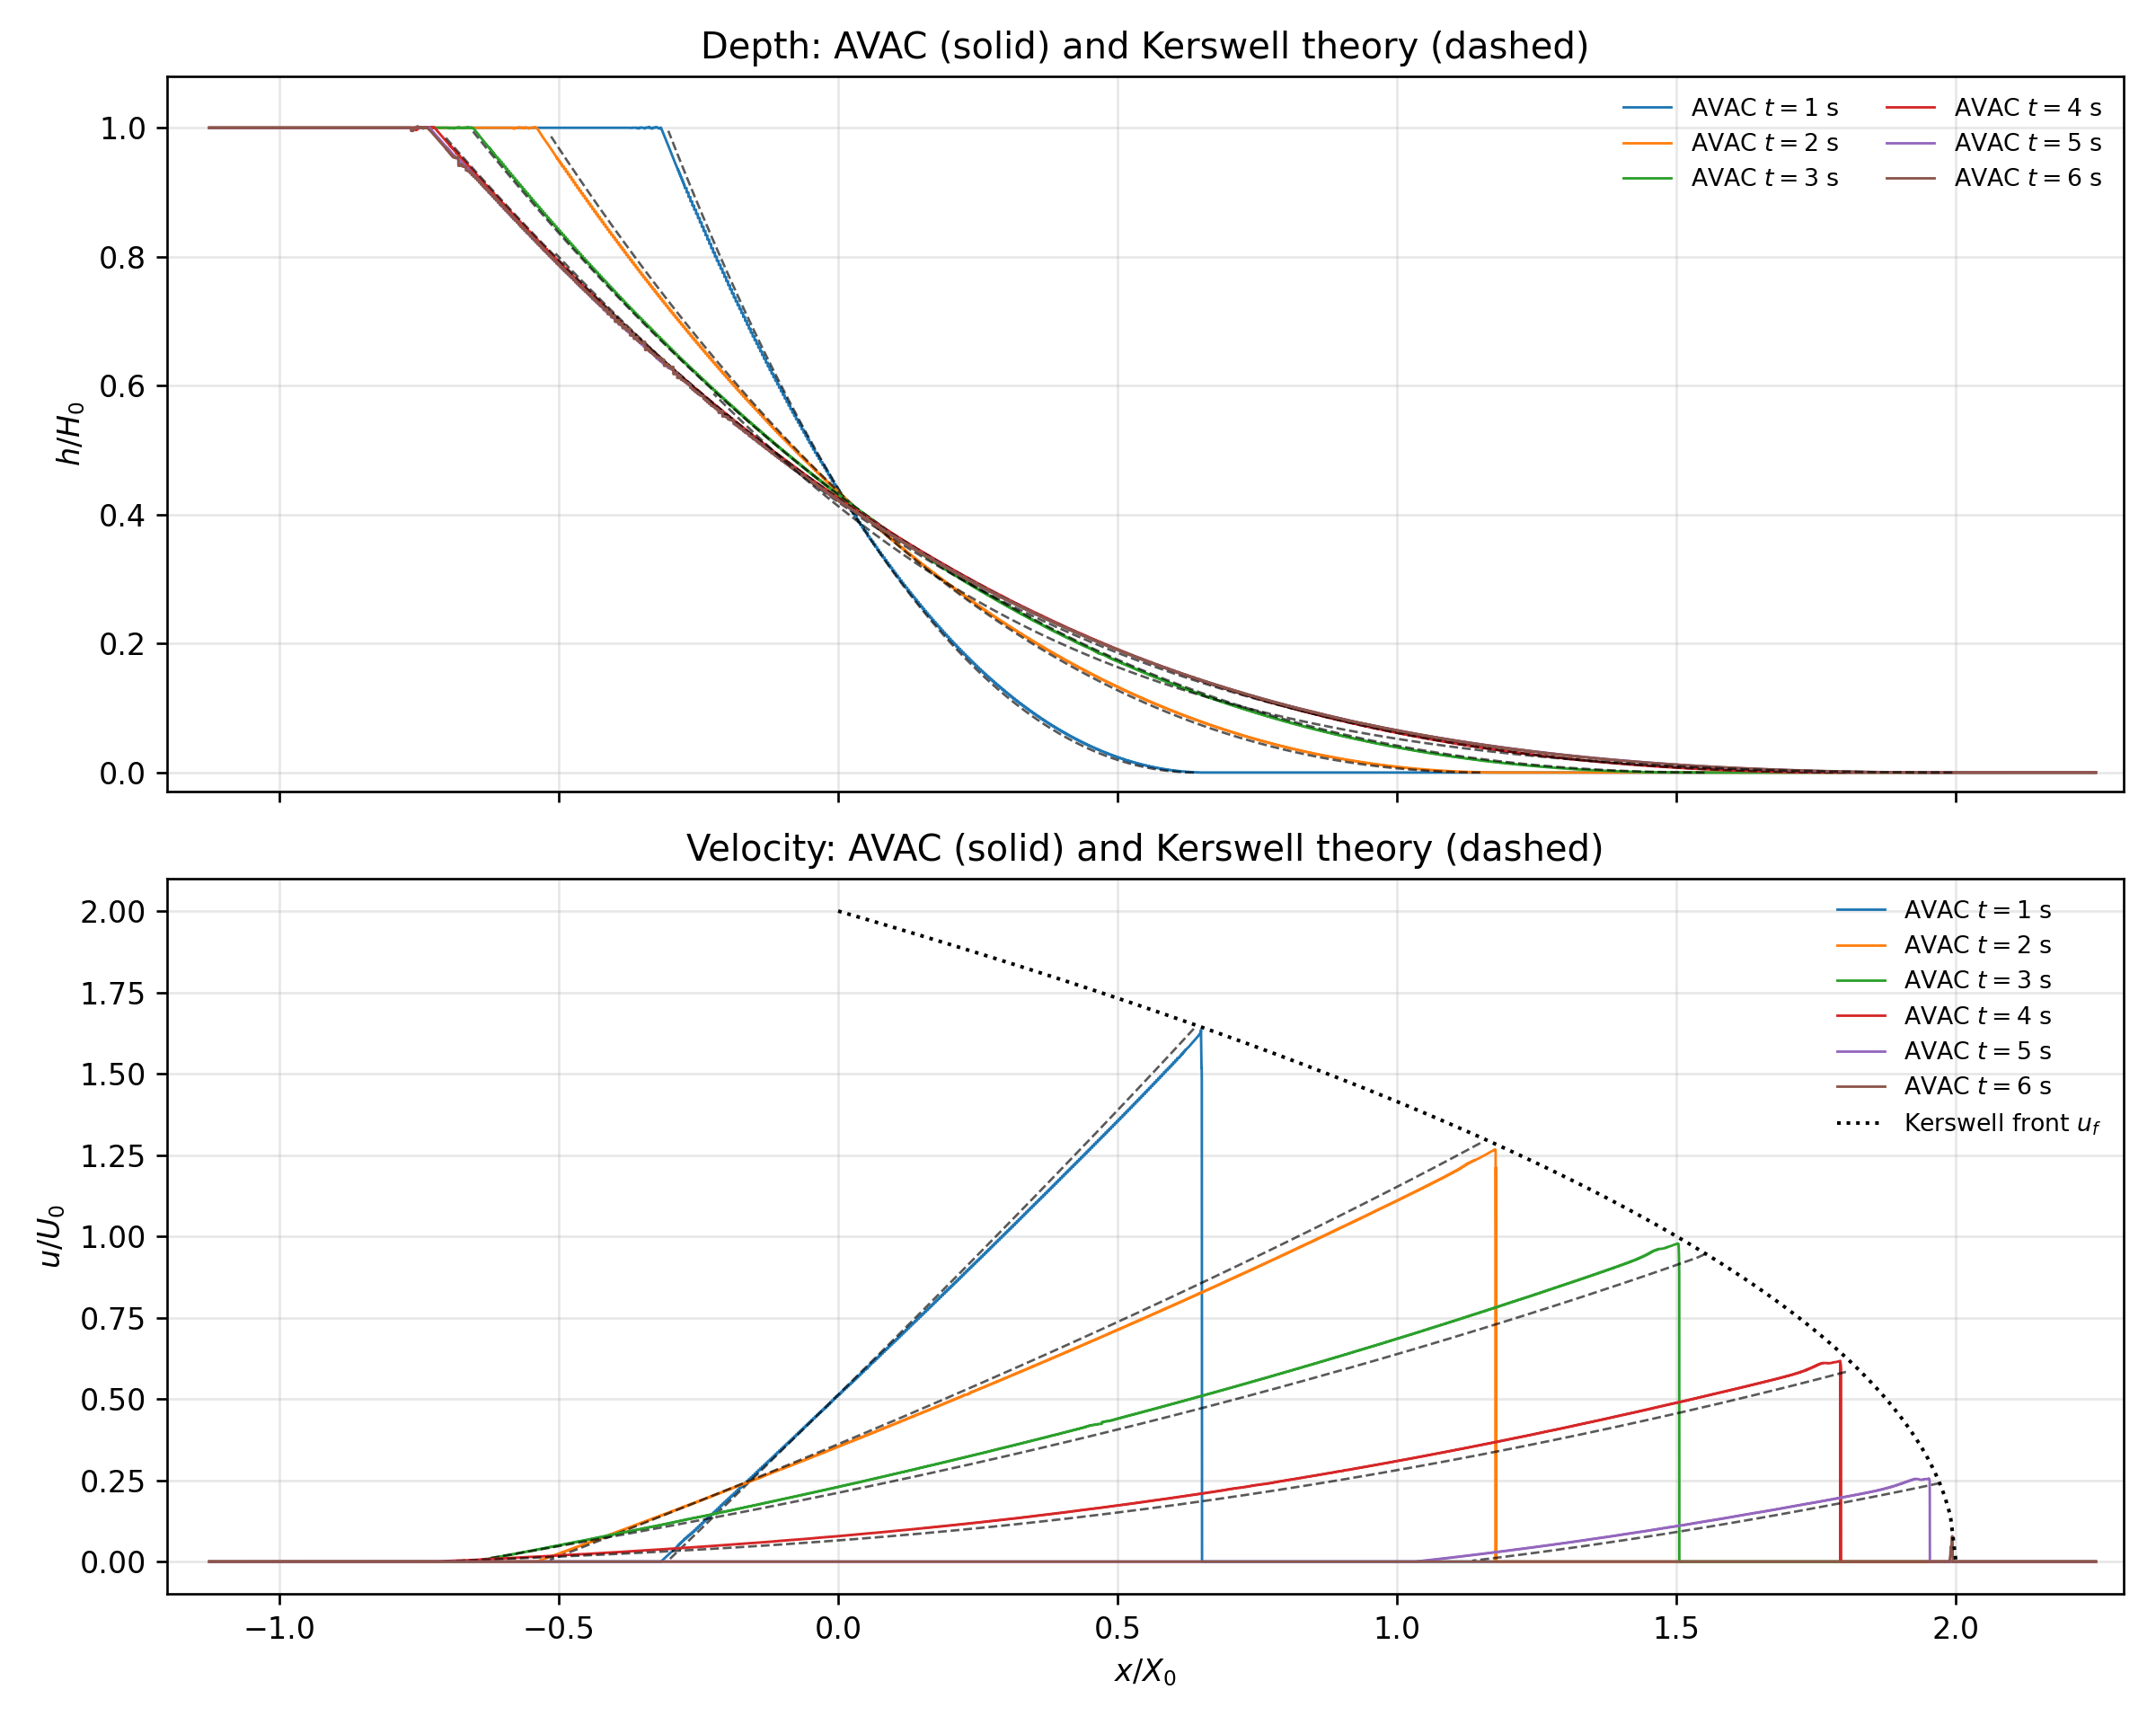

In [5]:
case.show(f'{RUN_NAME}/figures/boundary_positions_avac_vs_theory.png', f'{RUN_NAME}/figures/boundary_positions_dimensionless_avac_vs_theory.png', f'{RUN_NAME}/figures/characteristics_dimensionless.png', f'{RUN_NAME}/figures/flow-depth_dimensionless.png')
